# Notebook for Figure 2: Timeseries of the key parameters solar radiation, DMS, CS

Figures:
- Figure 2
- Figure 11
- Figure 12
- Figure S26
- Figure S27

In [34]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl
from matplotlib.colors import LogNorm, Normalize
from matplotlib import cm
import matplotlib.ticker as ticker
import statsmodels.api as sm
import matplotlib.dates as mdates

plt.rcParams["font.family"] = 'monospace'

In [2]:
def resample_monthly_sum(df, columns):
    """
    Resample daily data to monthly sums.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with daily data indexed by datetime
    columns : list
        Column names to sum
        
    Returns
    -------
    pd.DataFrame
        Monthly aggregated data with index as 'YYYY-MM' strings
    """
    df_monthly = df[columns].resample('ME').sum()
    df_monthly.index = pd.to_datetime(df_monthly.index).strftime('%Y-%m')
    return df_monthly

def save_plot(fig, filepath, dpi=300):
    """
    Save figure to file with automatic directory creation.
    
    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object to save
    filepath : str or Path
        Full path where to save the figure (e.g., 'path/to/figure.jpeg')
    dpi : int, optional
        Resolution in dots per inch (default: 300)
    """
    filepath = Path(filepath)
    filepath.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(filepath, bbox_inches='tight', dpi=dpi)
    print(f"Saved: {filepath}")

In [ ]:
# Define paths relative to notebook location
notebook_dir = Path.cwd()
project_root = notebook_dir.parent
data_file_path = project_root / 'Data' 
analysis_file_path = project_root / 'Analysis' 
plots_outpath = project_root / 'Plots'

DMS_dir = data_file_path / 'DMS'
Nano_ranking_dir = analysis_file_path / 'Nano_ranking'
classification_file_path = analysis_file_path / 'DalMaso_classification' / 'ZEP_classification.xlsx'

traj_solar_dir = analysis_file_path / 'traj_solar'

c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Data\DMS


In [69]:
# Define paths relative to notebook location
notebook_dir = Path(r'C:\Users\Dell\Documents\NAIS_work')
print(notebook_dir)

project_root = Path(r'C:\Users\Dell\Documents\NAIS_work')
data_file_path = project_root / 'data' 

analysis_file_path = project_root / 'Analysis' 
plots_outpath = project_root / 'Plots'

DMS_dir = data_file_path / 'DMS'
print(DMS_dir)
Nano_ranking_dir = project_root / 'ZEP_processed_files' / 'nano_ranking'  #C:\Users\Dell\Documents\NAIS_work\ZEP_processed_files\nano_ranking

#C:\Users\Dell\Documents\NAIS_work\Classification
classification_file_path = project_root / 'Classification' / 'ZEP_classification.xlsx'

traj_solar_dir = analysis_file_path / 'traj_solar'

C:\Users\Dell\Documents\NAIS_work
C:\Users\Dell\Documents\NAIS_work\data\DMS


In [70]:
def get_DMS_hr(DMS_dir):
    print(DMS_dir)
    DMS_files = sorted(str(p) for p in DMS_dir.glob('*'))
    print(DMS_files)

    df_DMS_2022 = pd.read_excel(DMS_files[0], skiprows=1, parse_dates=True, index_col=0)
    df_DMS_2022 = df_DMS_2022.replace(0, np.nan)
    df_DMS_2022.index = pd.to_datetime(df_DMS_2022.index, errors='coerce')
    df_DMS_2022 = df_DMS_2022.drop(columns=['Day of year'])

    df_DMS_2023 = pd.read_excel(DMS_files[-1], skiprows=0, parse_dates=True, index_col=0)
    df_DMS_2023 = df_DMS_2023.replace(0, np.nan)
    print(len(df_DMS_2023))
    df_DMS_2023.index = pd.to_datetime(df_DMS_2023.index, errors='coerce')
    df_DMS_2023 = df_DMS_2023.rename(columns={'DMS (pptv)':'Conc. (pptv)'})

    df_DMS = pd.concat([df_DMS_2022, df_DMS_2023])

    df_DMS_hourly = df_DMS.resample('h').mean(numeric_only=True)
    dates_DMS = df_DMS_hourly.index.date
    dates_DMS = [str(x).replace('-','') for x in dates_DMS]
    return df_DMS_hourly

def load_df(loadpath, extrapath=None, filename=None, formatdata=".dat", 
            dict_dtype=None,):
    """Load a dataframe from a file path that may be a string or a pathlib.Path."""
    base_path = Path(loadpath)

    if extrapath is not None:
        path = base_path / extrapath / f"{filename}{formatdata}"
    else:
        path = base_path / f"{filename}{formatdata}"

    print("loading: " + str(path))
    df = pd.read_csv(path, index_col=0, parse_dates=True,
                     dtype=dict_dtype)
    return df

def load_ZEP_class(classification_file_path):
    usecols = ['datetime','TE','burst','less than 50% of data','Und',
            'Non Event','snow','Event', 'comments', 'DMPS class','DMPS_count_class_daily',
            'Class Ia','Class Ib','Class II', 'Undefined','Non-event', 'too little data', 'maso comments',
            'windblown seen in DMPS']

    ZEP_class = pd.read_excel(classification_file_path, skiprows=1, usecols=usecols, index_col=0)
    ZEP_class = ZEP_class.dropna(how='all')

    comments = list(ZEP_class['comments'].values)
    noise = [x for x in comments if "noise" in str(x)]
    df_noise = ZEP_class[ZEP_class['comments'].isin(noise)]
    
    dalmaso_cols = ['Class Ia','Class Ib','Class II', 'Undefined','Non-event', 'too little data', 'maso comments', 'windblown seen in DMPS']
    integer_cols = ['Class Ia','Class Ib','Class II', 'Undefined','Non-event', 'too little data']

    ZEP_class = ZEP_class[dalmaso_cols].copy()
    ZEP_class[integer_cols] = ZEP_class[integer_cols].astype(float)
    ZEP_class = ZEP_class.dropna(how='all')

    ZEP_class['month'] = ZEP_class.index.month
    ZEP_class['year'] = ZEP_class.index.year
    ZEP_class['month_year'] = (ZEP_class['year']-2021)*12 + ZEP_class['month']

    ZEP_class['event'] = ZEP_class[['Class Ia', 'Class Ib', 'Class II']].sum(axis=1)
    ZEP_class['total'] = ZEP_class[['Class Ia', 'Class Ib', 'Class II', 'Undefined', 'Non-event']].sum(axis=1)
    ZEP_class['event_norm'] = ZEP_class['event']/ZEP_class['total']
    return ZEP_class

def get_monthly(ZEP_class):
    integer_cols = ['Class Ia','Class Ib','Class II', 'Undefined','Non-event', 'too little data']

    ZEP_class_monthly = resample_monthly_sum(ZEP_class, integer_cols)
    ZEP_class_monthly['event'] = ZEP_class_monthly[['Class Ia', 'Class Ib', 'Class II']].sum(axis=1)
    ZEP_class_monthly['total'] = ZEP_class_monthly[['Class Ia', 'Class Ib', 'Class II', 'Undefined', 'Non-event']].sum(axis=1)
    ZEP_class_monthly['event_norm'] = ZEP_class_monthly['event']/ZEP_class_monthly['total']
    ZEP_class_monthly.index = pd.to_datetime(ZEP_class_monthly.index)
    ZEP_freq = ZEP_class_monthly[['event_norm']].copy()
    return ZEP_freq

def rad_daily_average_for_time_resolution(df_rad, time_resolution=6):
    df_rad_6hr_sum = df_rad[['ghi']].resample('1h').mean()*time_resolution
    df_rad_6hr_sum_D = df_rad_6hr_sum.resample('D').mean()
    return df_rad_6hr_sum_D

def get_groupby_traj(df, var='SUN_FLUX', function=np.nanmean, 
                    select_for_mixedlayer=True): 
    if select_for_mixedlayer == True:
        df.loc[df['altitude'] >= df['MIXDEPTH'], var] = np.nan
    df_groupby = df.groupby('arrival_time').agg({var: function})
    df_groupby.index = pd.to_datetime(df_groupby.index)
    df_groupby = df_groupby.dropna()
    return df_groupby

In [71]:
df_DMS_hourly = get_DMS_hr(DMS_dir)

df_timeseries_90ratio20 = load_df(Nano_ranking_dir,
        filename='N_90ratio20')
df_timeseries_90minus20 = load_df(Nano_ranking_dir,
        filename='N_90-20')
df_timeseries_NintMax = load_df(Nano_ranking_dir,
        filename='N_int_max')

C:\Users\Dell\Documents\NAIS_work\data\DMS
['C:\\Users\\Dell\\Documents\\NAIS_work\\data\\DMS\\(KOPRI-ZEP) Atmospheric DMS mixing ratios in 2022.xlsx', 'C:\\Users\\Dell\\Documents\\NAIS_work\\data\\DMS\\DMS_ZEP_2023.xlsx']
4945
loading: C:\Users\Dell\Documents\NAIS_work\ZEP_processed_files\nano_ranking\N_90ratio20.dat
loading: C:\Users\Dell\Documents\NAIS_work\ZEP_processed_files\nano_ranking\N_90-20.dat
loading: C:\Users\Dell\Documents\NAIS_work\ZEP_processed_files\nano_ranking\N_int_max.dat


In [72]:
ZEP_class = load_ZEP_class(classification_file_path)

df_g_timeseries = pd.read_csv(Nano_ranking_dir / 'g_intensity_classification.dat',
                              index_col=0,
                              parse_dates=True)
df_g = df_g_timeseries.replace({'g1': 0, 'g2': 1, 'g3': 1})
df_g_ZEP_freq = ZEP_class.merge(df_g, left_index=True, right_index=True)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Dell\\Documents\\NAIS_work\\ZEP_processed_files\\nano_ranking\\g_intensity_classification.dat'

In [7]:
df_rad = pd.read_csv(analysis_file_path / 'Radiation' / 'GHI_Radiation.dat', index_col=0,
                    parse_dates=True)
df_CS_hourly = pd.read_csv(analysis_file_path / 'CS' / 'CS_hourly.dat',
                           index_col=0, parse_dates=True)

df_6hr = pd.read_csv(traj_solar_dir / 'solar_6hr.dat', index_col=0,
                    parse_dates=True)
df_12hr = pd.read_csv(traj_solar_dir / 'solar_12hr.dat', index_col=0,
                    parse_dates=True)
df_24hr = pd.read_csv(traj_solar_dir / 'solar_24hr.dat', index_col=0,
                    parse_dates=True)

In [8]:
df_CS_D = df_CS_hourly.resample('D').mean()
df_DMS_D = df_DMS_hourly.resample('D').mean()

df_rad_6hr_sum_D = rad_daily_average_for_time_resolution(df_rad) 

In [9]:
def merge(df_g_timeseries, ZEP_class, df_CS_hourly, df_intensity=None,
          sun_var='all_sunflux', time_hrs=6):
    """Merge event frequency, solar trajectory, and CS data into a daily DataFrame.

    Parameters
    ----------
    df_g_timeseries : pd.DataFrame
        Time series with the nano-ranking event flag.
    ZEP_class : pd.DataFrame
        Daily event classification from Dal Maso.
    df_CS_hourly : pd.DataFrame
        Hourly cloud-saturation data.
    df_intensity : pd.DataFrame, optional
        Intensity series for the same index. Defaults to the global
        ``df_timeseries_NintMax`` if it exists.
    sun_var : str
        Solar flux field to use for the SUN/CS ratio.
    time_hrs : int
        Trajectory time window in hours.
    """
    df_g = df_g_timeseries.replace({'g1': 0, 'g2': 1, 'g3': 1})
    ZEP_freq = ZEP_class[['event_norm']].copy()

    filename = f'solar_{time_hrs}hr.dat'
    df_hysplit_6hr_acc_sun_ml = pd.read_csv(
        traj_solar_dir / filename,
        index_col=0,
        parse_dates=True,
    )

    df_sun_cs_hr = df_hysplit_6hr_acc_sun_ml.merge(
        df_CS_hourly, left_index=True, right_index=True
    )
    df_sunflux_cs_hr = df_sun_cs_hr.copy()
    df_sunflux_cs_hr.index = pd.to_datetime(df_sunflux_cs_hr.index)

    df_sunflux_cs_D = df_sunflux_cs_hr.resample('D').mean()

    df_g_sunflux_cs_D = df_sunflux_cs_D.merge(df_g, left_index=True, right_index=True)
    df_g_sunflux_cs_D_freq = df_g_sunflux_cs_D.merge(ZEP_freq, left_index=True, right_index=True)

    if df_intensity is None:
        df_intensity = globals().get('df_timeseries_NintMax', None)

    if df_intensity is not None:
        df_g_sunflux_cs_D_freq_N = df_intensity.merge(
            df_g_sunflux_cs_D_freq, left_index=True, right_index=True
        )
    else:
        df_g_sunflux_cs_D_freq_N = df_g_sunflux_cs_D_freq.copy()

    df_g_sunflux_cs_D_freq_N['SUN_CS'] = (
        df_g_sunflux_cs_D_freq_N[sun_var] / df_g_sunflux_cs_D_freq_N['CS']
    )
    return df_g_sunflux_cs_D_freq_N


In [10]:
time_hrs=6
filename='solar_'+str(time_hrs)+'hr.dat'
df_hysplit_6hr_acc_sun_ml = pd.read_csv(traj_solar_dir / filename,
                                             index_col=0, parse_dates=True)

In [11]:
df_g_sunflux_cs_D_freq_N = merge(df_g_timeseries, ZEP_class, df_CS_hourly,
                                 df_timeseries_NintMax)

df_g_sunflux_cs_D_freq_N_DMS = df_g_sunflux_cs_D_freq_N.merge(df_DMS_D, left_index=True, right_index=True, how='left')

In [12]:
def quick_timeseries_plot(df_rad_6hr_sum_D, df_hysplit_6hr_acc_sun_ml,
                          df_timeseries_NintMax, df_CS_D, df_DMS_D, 
                          intensity_parameter='N_int_max', 
                          ylabel='$\Delta$N$_{\mathrm{2.8-5nm, max}}$ [cm$^{-3}$]', 
                          sunmax=2000, window=30, min_periods=7, s_dot=1): 
    fig, (ax, subax)  = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    fig:plt.Figure
    ax: plt.Axes

    ax.text(.01, .9, 'a)', transform=ax.transAxes)
    ax.plot(df_rad_6hr_sum_D.index, df_rad_6hr_sum_D['ghi'].values, 'o', ms=1, c='r', alpha=.1)
    x = df_rad_6hr_sum_D.index
    y = df_rad_6hr_sum_D['ghi'].values
    ax.fill_between(x, y, color='red', alpha=.1)

    df_sunflux_D = df_hysplit_6hr_acc_sun_ml.resample('D').mean()
    ax.bar(df_sunflux_D.index, 
           df_sunflux_D['all_sunflux'].values, color='yellow', alpha=.5)     
    ax.bar(df_sunflux_D.index, 
           df_sunflux_D['SUN_FLUX'].values, color='orange', alpha=1) 

    ax.set_ylabel('Solar insolation\n[hWm$^{-2}$]', color='orange', 
                  zorder=2, labelpad=30, fontsize=15) #Acc. 6hr solar flux along traj
    ax.set_ylim(0, sunmax)
    #ax.yaxis.tick_left()
    ax.yaxis.set_label_position("right")
    
    ax2 = ax.twinx()
    ax2.text(.01, -.3, 'b)', transform=ax2.transAxes)

    ax2.scatter(df_timeseries_NintMax.index, 
                df_timeseries_NintMax[intensity_parameter], 
                s=s_dot,alpha=.5, c='k')
    ax2.set_ylabel(ylabel, color='k', fontsize=15, labelpad=30)   
    ax2.plot(df_timeseries_NintMax.index, 
             df_timeseries_NintMax[intensity_parameter].rolling(window=window, 
                                                       center=True, 
                                                       min_periods=min_periods).mean(), 
             label='$\Delta$N$_{2.8-5 nm}$ '+str(window)+'-d roll. mean (min. '+str(min_periods)+'d)', c='k', zorder=20)
    ax2.legend(frameon=False)    
    ax2.set_ylim(0,sunmax)
    
    ax2.set_ylabel(ylabel, color='k', fontsize=15, labelpad=30) 
    ax2.yaxis.set_label_position("left")

       
    subax.plot(df_DMS_D.index, df_DMS_D['Conc. (pptv)'].values, 
               'o', color='green', ms=1, alpha=.5)
    subax.plot(df_DMS_D.index, df_DMS_D['Conc. (pptv)'].rolling(window=window, center=True, 
                                                    min_periods=min_periods).mean(), 
             label='DMS '+str(window)+'-d roll. mean (min. '+str(min_periods)+'d window centred)', 
             c='g', lw=2)
    subax.set_ylabel('DMS [pptv]', color='green', zorder=2, fontsize=15)
    subax.set_ylim(0, 350)

    subax2 = subax.twinx()
    subax2.scatter(df_CS_D.index,df_CS_D['CS'],s=s_dot,alpha=.5, c='k')
    subax2.plot(df_CS_D.index, df_CS_D['CS'].rolling(window=window, center=True, 
                                                    min_periods=min_periods).mean(),
             label='CS '+str(window)+'-d roll. mean (min. '+str(min_periods)+'d window centred)', c='k', zorder=20, lw=.5, 
             ms=1, alpha=1)
    subax2.set_ylabel('CS [s$^{-1}$] ', color='k', fontsize=15, labelpad=3)  
    subax2.set_yscale('log')
    subax2.set_ylim(10**(-6), 10**(-2))

    subax2.legend(frameon=False)
    subax.legend(frameon=False, loc=4)
    
    ax.set_xlim(pd.to_datetime('2022-04-01'), pd.to_datetime('2024-10-30'))
    subax.set_xlim(pd.to_datetime('2022-04-01'), pd.to_datetime('2024-10-30'))

    polar_night_events = ['2022-10-10', '2022-10-15', '2022-10-16', '2022-11-25', '2023-10-26', '2023-10-28', '2023-11-01', '2023-11-03']
    polar_night_events = ['2022-11-25', '2022-11-26', '2023-10-25', '2023-10-26', '2023-10-28', '2023-10-29', '2023-11-01', '2023-11-02', '2023-11-02', 
                          '2023-11-03']
    for polar_night_event in polar_night_events:
        polar_night_event = pd.to_datetime(polar_night_event)
        ax.axvline(polar_night_event, ymin=0, ymax=2000, ls=':', lw=2, alpha=.5)
    
    plt.show()
    return fig

<>:4: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:39: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:4: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:39: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_12436\2974981450.py:4: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  ylabel='$\Delta$N$_{\mathrm{2.8-5nm, max}}$ [cm$^{-3}$]',
C:\Users\Dell\AppData\Local\Temp\ipykernel_12436\2974981450.py:39: SyntaxWarning: "\D" is an invalid escape seque

## Figure 2: 

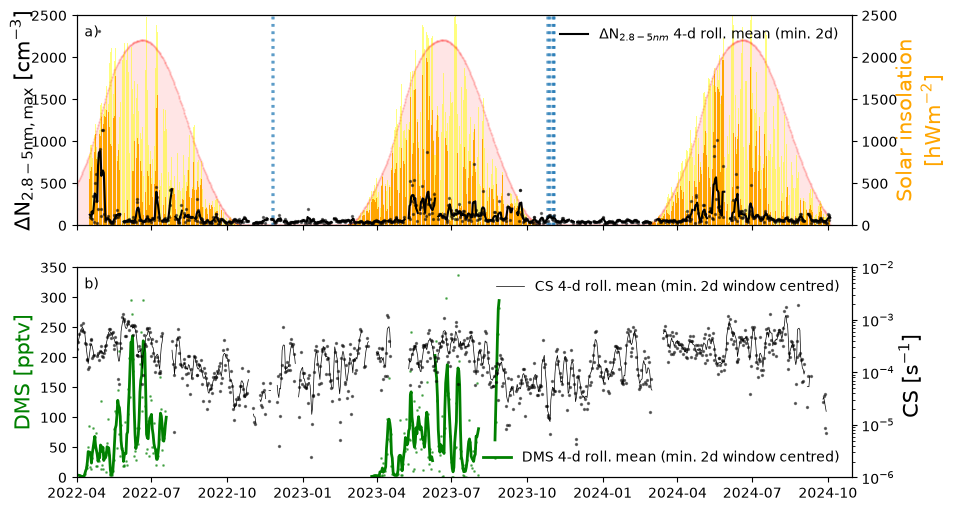

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\Figure_2.jpeg


In [13]:
fig = quick_timeseries_plot(df_rad_6hr_sum_D, df_hysplit_6hr_acc_sun_ml,
                            df_timeseries_NintMax, df_CS_D, df_DMS_D, 
                            intensity_parameter='N_int_max', window=4, min_periods=2,
                            sunmax=2500, s_dot=2)

output_figure = plots_outpath / 'Figure_2.jpeg'
save_plot(fig, output_figure)

In [14]:
df_sunflux_D = df_hysplit_6hr_acc_sun_ml.resample('D').mean()
df_sunflux_D_rad = df_sunflux_D.merge(df_rad_6hr_sum_D, 
                            left_index=True, right_index=True)

df_sunflux_D_rad['norm_sun'] = df_sunflux_D_rad['SUN_FLUX']/df_sunflux_D_rad['ghi']

In [15]:
def thickax(ax, fontsize=12):
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(1.5)
    plt.rc('axes', linewidth=1.5)    
    ax = plt.gca()
    for tick in ax.xaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_fontsize(fontsize)
    ax.tick_params(direction='out', length=7, width=1.5, pad=12, bottom=True, top=False, left=True, right=False)

In [16]:
def quick_timeseries_plot_v3(df, intensity_parameter='N_int_max', event_freq_dalmaso='event_norm',
                          ylabel='$\Delta$N$_{\mathrm{2.8-5nm, max}}$ [cm$^{-3}$]', 
                          window=30, min_periods=7, lw=1.5, suncsmax=9, sunmax=2000): 
    fig, ax  = plt.subplots(1, 1, figsize=(10, 3))
    fig:plt.Figure
    ax: plt.Axes
    ax.plot(df.index, df[event_freq_dalmaso].rolling(window=window, 
                                                       center=True, 
                                                       min_periods=min_periods).mean(), c='green', 
             label='Class Ia, Ib, II (Dal Maso)', alpha=.5)
    ax.scatter(df.index, df['g'], s=.1,alpha=.5, c='b')
    ax.plot(df.index, df['g'].rolling(window=window, 
             center=True, min_periods=min_periods).mean(), c='blue', alpha=.5,
             label='g2g3 (Aliaga)\n'+str(window)+'-day roll. mean (min. window '+str(min_periods)+'d)')
    ax.set_ylabel('Event frequency [-]', color='k', fontsize=15,) 
    ax.legend(loc=1, frameon=False)
    ax.set_ylim(0,.9)
    ax2 = ax.twinx()    
    ax2.scatter(df.index, df['SUN_CS'], s=.1,alpha=.5, c='r')
    ax2.plot(df.index, df['SUN_CS'].rolling(window=window, 
                            center=True, 
                            min_periods=min_periods).mean(), 
                            c='r', zorder=20, lw=1.5)
    ax2.set_ylabel('SUN FLUX/CS\n[h Wm$^{-2}$s] (x10$^{6}$)', color='r', 
                     fontsize=12, labelpad=3) 
    ax2.legend(loc=2, frameon=False)    
    ax2.set_yticks(np.arange(0,suncsmax*10**6,2*10**6), 
                       np.arange(0,suncsmax,2))
    ax2.set_ylim(0, suncsmax*10**6)
    
    twin2 = ax.twinx()
    twin2.spines['right'].set_position(("axes", 1.15))
    twin2.scatter(df.index,df[intensity_parameter],s=.1,alpha=.5, c='k')
    twin2.plot(df.index, df[intensity_parameter].rolling(window=window, center=True, 
                min_periods=min_periods).mean(),
             label='$\Delta$N$_{2.8-5 nm}$ '+str(window)+'-d roll. mean (min. '+str(min_periods)+'d)', 
             c='k', zorder=20, ms=1, alpha=1, lw=1.5)
    twin2.set_ylim(0,sunmax)
    twin2.legend(frameon=False, loc=2)
    twin2.set_ylabel('$\Delta$N$_{2.8-5 \mathrm{nm}}$ [cm$^{-3}$]', color='k', 
                     fontsize=15, labelpad=.1) 
    ax.set_title(str(window)+'-day rolling mean', loc='left', fontsize=12)    
    plt.show()
    return fig

<>:2: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:36: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:40: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:2: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:36: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:40: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_12436\3750257368.py:2: SyntaxWarnin

C:\Users\Dell\AppData\Local\Temp\ipykernel_12436\3750257368.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc=2, frameon=False)


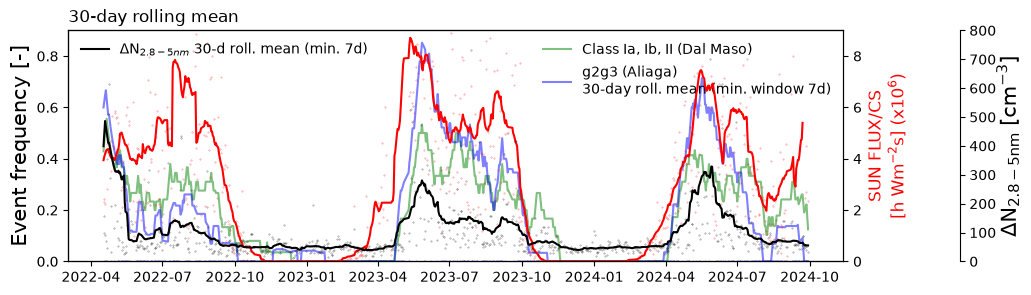

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\Figure_11.jpeg


In [17]:
fig = quick_timeseries_plot_v3(df_g_sunflux_cs_D_freq_N, sunmax=800, suncsmax=9)

output_figure = plots_outpath / 'Figure_11.jpeg'
save_plot(fig, output_figure)

In [18]:
def create_colourbar(cax, vmin=10**(-1), vmax=10**4, cmap='jet', extend='both', 
                     colourbar_label=r'Rolling window [days]', fontsize=12,
                     scientific_notation=True, log_scale=False, orientation='vertical', labels=None):
    if log_scale == True:
        norm = LogNorm(vmin, vmax)
    if log_scale == False:
        norm = Normalize(vmin, vmax)
    fmt = None
    if cmap is None:
        cmap = plt.get_cmap('magma')
    elif isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)
    if scientific_notation == True:
        fmt = ticker.ScalarFormatter(useMathText=True)
        fmt.set_powerlimits((-2, 4))

    cb = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm, orientation=orientation)
    cb.set_label(colourbar_label, fontsize=fontsize)
    cb.ax.tick_params(labelsize=fontsize)
    cb.ax.yaxis.set_offset_position('left')    
    cb.ax.yaxis.get_offset_text().set_fontsize(fontsize)    
    cb.update_ticks()
    
    if labels is not None:
        cb.set_ticklabels(labels)
        locs=[vmin, vmax]
        cb.set_ticks(locs)
        
    return cb 

In [19]:
def quick_timeseries_rolling(df, windows=[2, 5, 5, 7, 10, 14, 30],
                          ylabel='$\Delta$N$_{\mathrm{2.8-5nm, max}}$ [cm$^{-3}$]',
                          min_periods=1): 
    fig = plt.figure(figsize=(8, 6))
    gs = gridspec.GridSpec(ncols=16, nrows=6, hspace = .5, wspace=14, top = 1,
                           bottom = 0, left = 0, right = 1)
    ax = fig.add_subplot(gs[0:2, 0:14]) 
    n = len(windows)
    cmap = plt.cm.copper_r
    colors = [mpl.colors.rgb2hex(cmap(i)) for i in np.linspace(0, 1, n)]
    
    for i, window in enumerate(windows):
        ax.plot(df.index, df['g'].rolling(window=window, 
                    center=True, min_periods=min_periods).mean(), c=colors[i], 
                alpha=.5, label=str(window))
    ax.scatter(df.index, df['g'], s=.1,alpha=.5, c='b')
    ax.set_ylabel('Event freq.\nNano-ranking [-]', fontsize=10)  
    ax.set_ylim(0, 1)

    ax = fig.add_subplot(gs[2:4, 0:14]) 
    for i, window in enumerate(windows):
        ax.plot(df.index, df['event_norm'].rolling(window=window, 
                    center=True, min_periods=min_periods).mean(), c=colors[i], 
                alpha=.6, label=str(window))
    ax.scatter(df.index, df['event_norm'], s=.1,alpha=.6, c='b')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Event freq.\nDalMaso [-]', fontsize=10)  

    ax = fig.add_subplot(gs[4:6, 0:14]) 
    for i, window in enumerate(windows):
        ax.plot(df.index, df['N_int_max'].rolling(window=window, 
                center=True, min_periods=min_periods).mean(), c=colors[i], 
                alpha=.6, label=str(window))
    ax.scatter(df.index, df['N_int_max'], s=.1,alpha=.6, c='b')
    ax.set_ylim(0, 1500)

    ax.set_ylabel(ylabel, fontsize=10)    
    cax = fig.add_subplot(gs[0:6, 14:16])
    create_colourbar(cax, cmap = cmap, vmin=windows[0], vmax=windows[-1])
    plt.show()
    return fig

<>:2: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:2: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_12436\1183820797.py:2: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  ylabel='$\Delta$N$_{\mathrm{2.8-5nm, max}}$ [cm$^{-3}$]',


## For the review process: 

<>:2: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:2: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_12436\3010861904.py:2: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  ylabel='$\Delta$N$_{\mathrm{2.8-5nm, max}}$ [cm$^{-3}$]',


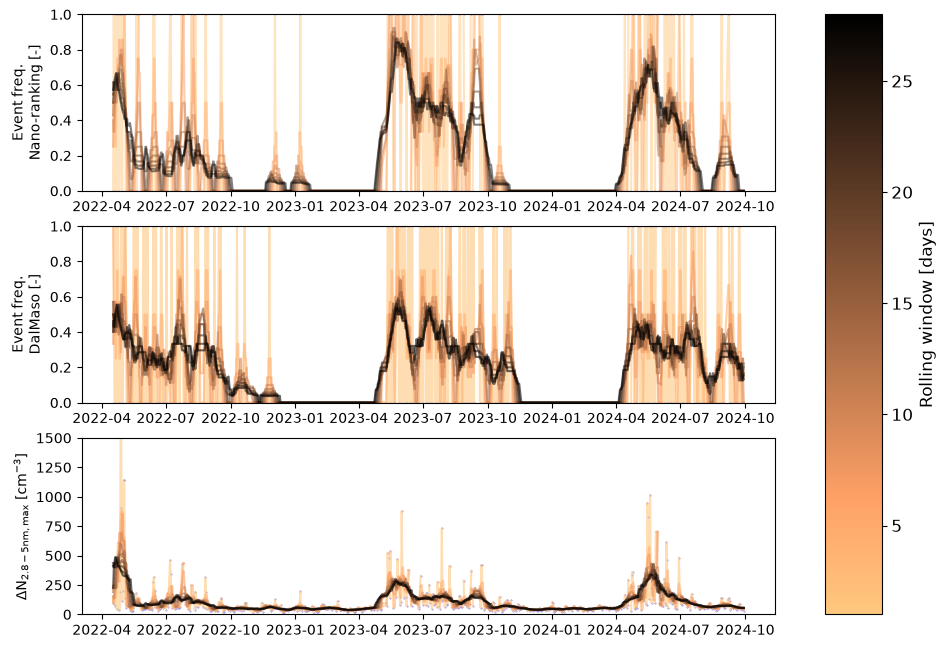

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\Figure_review.jpeg


In [20]:
fig = quick_timeseries_rolling(df_g_sunflux_cs_D_freq_N, windows=np.arange(1, 30, 3),
                          ylabel='$\Delta$N$_{\mathrm{2.8-5nm, max}}$ [cm$^{-3}$]',
                          min_periods=1)

output_figure = plots_outpath / 'Figure_review.jpeg'
save_plot(fig, output_figure)

# OLS: 

In [21]:
def OLS_plot(df_g_sunflux_cs_D_freq_N, dep_var='SUN_CS', indep_var='event_norm',
             window=30, min_periods=7, xlabel='Event Frequency (DalMaso, rolling mean applied)'):
    df = df_g_sunflux_cs_D_freq_N[[indep_var, dep_var]].copy()
    df = df.dropna(how='any').copy() 
    df_roll_depvar = df[dep_var].rolling(window=window, center=True, min_periods=min_periods).mean().to_frame(dep_var)
    df_roll_indepvar = df[indep_var].rolling(window=window, center=True, min_periods=min_periods).mean().to_frame(indep_var)
    X = df_roll_indepvar[indep_var]
    y = df_roll_depvar[dep_var]
    # Add constant for OLS intercept
    X = sm.add_constant(X)
    # Fit OLS model
    model = sm.OLS(y, X).fit()
    # Get coefficients
    intercept, slope = model.params
    # R-squared
    r2 = model.rsquared
    print("OLS Equation: ROI_roll = {:.4f} + {:.4f} * Nano_roll".format(intercept, slope))
    print("R² = {:.4f}".format(r2))
    # Plot scatter + regression line
    fig, ax = plt.subplots(figsize=(4,4))
    plt.scatter(df_roll_indepvar[indep_var].values, 
                df_roll_depvar[dep_var].values, alpha=0.7, c='k')
    plt.plot(df_roll_indepvar[indep_var].values, intercept + slope*df_roll_indepvar[indep_var].values, color="red", ls=':',
            label="OLS:\ny = {:.0f} + {:.0f} * x".format(intercept, slope)+"\nR² = {:.2f}".format(r2))
    plt.xlabel(indep_var)
    plt.xlabel(xlabel)
    plt.ylabel(dep_var)
    plt.ylabel('SUN/CS ('+str(window)+' day rolling mean applied)')
    plt.title("OLS Regression: "+str(dep_var.replace('_','/'))+" vs. "+str(indep_var))
    plt.legend(frameon=False, loc=2, 
               bbox_to_anchor=(1.04, 1), borderaxespad=0)
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.tick_params(axis='both', which='minor', labelsize=15)
    plt.grid(True)
    #ax.set_xlim(0, 1)
#     ax.set_ylim(0,1)
    #ax.plot(np.arange(0,1,.1), np.arange(0,1,.1), ':', c='k', alpha=.5)
    plt.show()
    return fig

OLS Equation: ROI_roll = 890766.8450 + 11835206.5848 * Nano_roll
R² = 0.5680


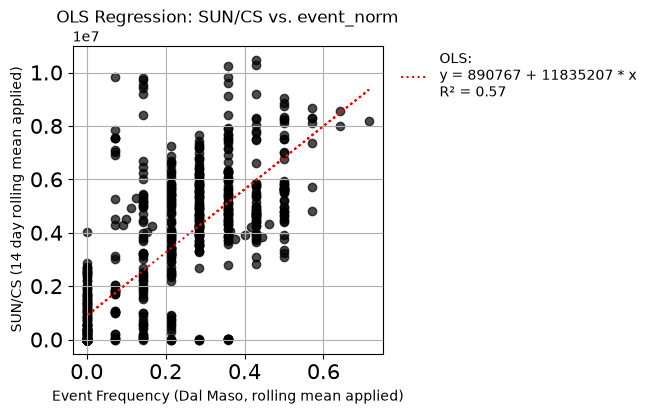

In [22]:
## Compare event frequency (Dal Maso) with SUN/CS: 

fig = OLS_plot(df_g_sunflux_cs_D_freq_N, indep_var='event_norm',
               window=14, min_periods=3, 
               xlabel='Event Frequency (Dal Maso, rolling mean applied)')

OLS Equation: ROI_roll = 1294770.4731 + 8661090.4923 * Nano_roll
R² = 0.6360


<>:5: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:5: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_12436\4219892651.py:5: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  xlabel='Event frequency ($\Delta$N, rolling mean applied)')


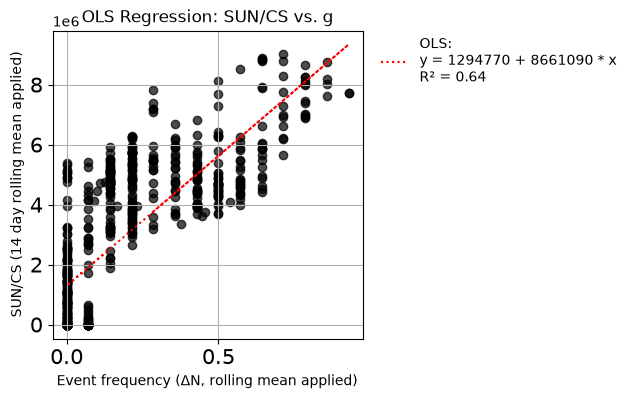

In [23]:
## Compare event frequency (nanoranking) with SUN/CS: 

fig = OLS_plot(df_g_sunflux_cs_D_freq_N, indep_var='g',
               window=14, min_periods=2, 
               xlabel='Event frequency ($\Delta$N, rolling mean applied)')

<>:5: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:5: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_12436\775458060.py:5: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  xlabel='Event Strength ($\Delta$N, rolling mean applied)')


OLS Equation: ROI_roll = 846721.8133 + 20373.4512 * Nano_roll
R² = 0.4462


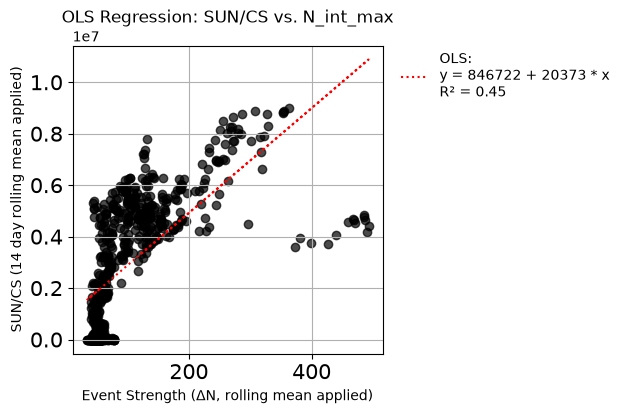

In [24]:
#Nano ranking instensity with SUN/CS: 

fig = OLS_plot(df_g_sunflux_cs_D_freq_N, indep_var='N_int_max',
               window=14, min_periods=2, 
               xlabel='Event Strength ($\Delta$N, rolling mean applied)')

## OLS with colour

In [25]:
def OLS_colour_plot(df_g_sunflux_cs_D_freq_N, dep_var='SUN_CS', indep_var='event_norm',
             window=30, min_periods=7, xlabel='Event Frequency (DalMaso, rolling mean applied)', suncsmax=10):

    df = df_g_sunflux_cs_D_freq_N[[indep_var, dep_var]].copy()
    df = df.dropna(how='any').copy() 
    df_roll_depvar = df[dep_var].rolling(window=window, center=True, min_periods=min_periods).mean().to_frame(dep_var)
    df_roll_indepvar = df[indep_var].rolling(window=window, center=True, min_periods=min_periods).mean().to_frame(indep_var)
    X = df_roll_indepvar[indep_var]
    y = df_roll_depvar[dep_var]
    # Add constant for OLS intercept
    X = sm.add_constant(X)
    # Fit OLS model
    model = sm.OLS(y, X).fit()
    # Get coefficients
    intercept, slope = model.params
    # R-squared
    r2 = model.rsquared
    print("OLS Equation: ROI_roll = {:.4f} + {:.4f} * Nano_roll".format(intercept, slope))
    print("R² = {:.4f}".format(r2))
    # Plot scatter + regression line
    fig, ax = plt.subplots(figsize=(4,4))

    dates = df.index
    date_nums = mdates.date2num(dates)
    months = dates.to_period("M").astype(str)

#     sc = plt.scatter(df_roll_indepvar[indep_var].values, 
#                 df_roll_depvar[dep_var].values, alpha=0.7,
#                 c=date_nums, cmap="viridis") 
        
    sc = plt.scatter(df_roll_indepvar[indep_var].values, 
                df_roll_depvar[dep_var].values, alpha=0.7,
                c=pd.Categorical(months).codes, cmap="tab20")
    
    ax.plot(df_roll_indepvar[indep_var].values, intercept + slope*df_roll_indepvar[indep_var].values, color="k", ls='-', alpha=.8,
            label="OLS:\ny = {:.0f} + {:.0f} * x".format(intercept, slope)+"\nR² = {:.2f}".format(r2))
    ax.legend()
    plt.xlabel(xlabel)

    plt.ylabel('SUN/CS (rolling '+str(window)+'-day mean applied) [10$^{6}$]')
    plt.title("OLS: "+str(dep_var.replace('_','/'))+" vs. Nano-ranking freq:\ny = {:.0f}x + {:.0f}".format(slope, intercept)+", R² = {:.2f}".format(r2))
    plt.legend(frameon=False, loc=2, 
               bbox_to_anchor=(1.08, 1.1), borderaxespad=0)
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.tick_params(axis='both', which='minor', labelsize=15)
    ax.set_xlim(0,1)
    ax.set_yticks(np.arange(0,suncsmax*10**6,2*10**6), 
                       np.arange(0,suncsmax,2))
    ax.set_ylim(0, suncsmax*10**6)

    # cbar = plt.colorbar(sc)
    # cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    # cbar.set_label("Date")

    handles, _ = sc.legend_elements(num=None)
    plt.legend(handles, sorted(set(months)), 
               title="Month", bbox_to_anchor=(1.05, 1), loc="upper left",
               ncol=3, frameon=False)


    plt.grid(True)
    plt.show()
    return fig

<>:3: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:3: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\Dell\AppData\Local\Temp\ipykernel_12436\3321242655.py:3: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  xlabel='Nano-ranking event frequency\n($\Delta$N, rolling 30-day mean applied)')


OLS Equation: ROI_roll = 1115564.0806 + 9599201.7097 * Nano_roll
R² = 0.7154


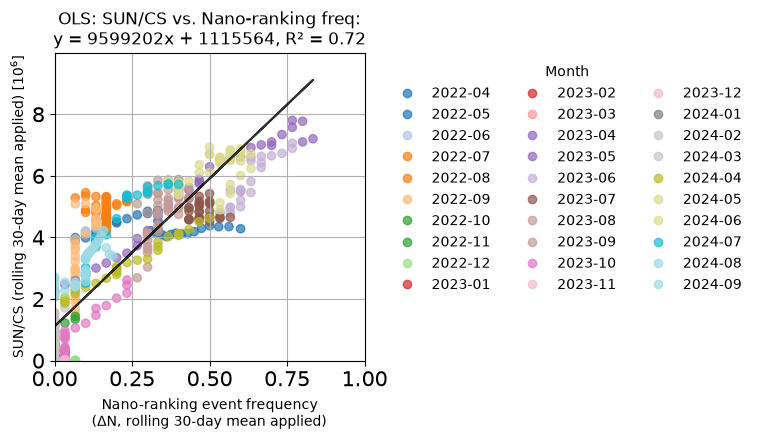

Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\Figure_S26.jpeg


In [26]:
fig = OLS_colour_plot(df_g_sunflux_cs_D_freq_N, indep_var='g',
               window=30, min_periods=1, 
               xlabel='Nano-ranking event frequency\n($\Delta$N, rolling 30-day mean applied)')

output_figure = plots_outpath / 'Figure_S26.jpeg'
save_plot(fig, output_figure)

# R2 PLOTS: 

In [27]:
def OLS_r2(df_g_sunflux_cs_D_freq_N, dep_var='SUN_CS', indep_var='event_norm',
           window=30, min_periods=7):
    """Calculate R² for OLS regression with rolling window.
    
    Parameters
    ----------
    df_g_sunflux_cs_D_freq_N : pd.DataFrame
        Input data with independent and dependent variables
    dep_var : str
        Name of dependent variable column
    indep_var : str
        Name of independent variable column
    window : int
        Rolling window size
    min_periods : int
        Minimum periods required for rolling calculation
        
    Returns
    -------
    float
        R² value for the OLS model
    """
    df = df_g_sunflux_cs_D_freq_N[[indep_var, dep_var]].copy()
    df = df.dropna(how='any')
    df_roll_depvar = df[dep_var].rolling(window=window, center=True, min_periods=min_periods).mean().to_frame(dep_var)
    df_roll_indepvar = df[indep_var].rolling(window=window, center=True, min_periods=min_periods).mean().to_frame(indep_var)
    X = sm.add_constant(df_roll_indepvar[indep_var])
    y = df_roll_depvar[dep_var]
    model = sm.OLS(y, X).fit()
    return model.rsquared


def df_r2(df_g_sunflux_cs_D_freq_N, dep_var='SUN_CS', indep_var='event_norm'):
    """Compute R² values across a range of rolling window sizes.
    
    Parameters
    ----------
    df_g_sunflux_cs_D_freq_N : pd.DataFrame
        Input data with independent and dependent variables
    dep_var : str
        Name of dependent variable column
    indep_var : str
        Name of independent variable column
        
    Returns
    -------
    pd.DataFrame
        DataFrame with columns 'windows' and 'r2s'
    """
    r2s = []
    windows = []
    for window in np.arange(1, 50, 1):
        r2 = OLS_r2(
            df_g_sunflux_cs_D_freq_N,
            dep_var=dep_var,
            indep_var=indep_var,
            window=window,
            min_periods=1,
        )
        r2s.append(r2)
        windows.append(window)
    return pd.DataFrame({'windows': windows, 'r2s': r2s})


def get_r2dfs_events(df_g_timeseries, ZEP_class, df_CS_hourly, time_hrs=24, sun_var='SUN_FLUX'):
    """Compute R² DataFrames for event frequency analysis across multiple time horizons.
    
    Parameters
    ----------
    df_g_timeseries : pd.DataFrame
        Nano-ranking event classification time series
    ZEP_class : pd.DataFrame
        Dal Maso event classification
    df_CS_hourly : pd.DataFrame
        Hourly cloud saturation data
    time_hrs : int
        Trajectory averaging window in hours
    sun_var : str
        Solar flux variable name ('SUN_FLUX' or 'all_sunflux')
        
    Returns
    -------
    tuple
        Four DataFrames: (SUN/CS vs Dal Maso, SUN/CS vs Nano, SUN vs Dal Maso, SUN vs Nano)
    """
    df_g_sunflux_cs_D_freq_N = merge(
        df_g_timeseries,
        ZEP_class,
        df_CS_hourly,
        df_intensity=df_timeseries_NintMax,
        time_hrs=time_hrs,
        sun_var=sun_var,
    )

    df_SUNCS_Dalmaso = df_r2(df_g_sunflux_cs_D_freq_N, dep_var='SUN_CS', indep_var='event_norm')
    df_SUNCS_Nano = df_r2(df_g_sunflux_cs_D_freq_N, dep_var='SUN_CS', indep_var='g')
    df_SUNFLUX_Dalmaso = df_r2(df_g_sunflux_cs_D_freq_N, dep_var=sun_var, indep_var='event_norm')
    df_SUNFLUX_Nano = df_r2(df_g_sunflux_cs_D_freq_N, dep_var=sun_var, indep_var='g')
    return df_SUNCS_Dalmaso, df_SUNCS_Nano, df_SUNFLUX_Dalmaso, df_SUNFLUX_Nano


In [42]:
df_SUNCS_Nano6

,windows,r2s
0,1,0.197727
1,2,0.304090
2,3,0.376218
3,4,0.424334
4,5,0.459375
5,6,0.488310
6,7,0.512813
7,8,0.538727
8,9,0.560075
9,10,0.579571


Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\Figure_12.jpeg


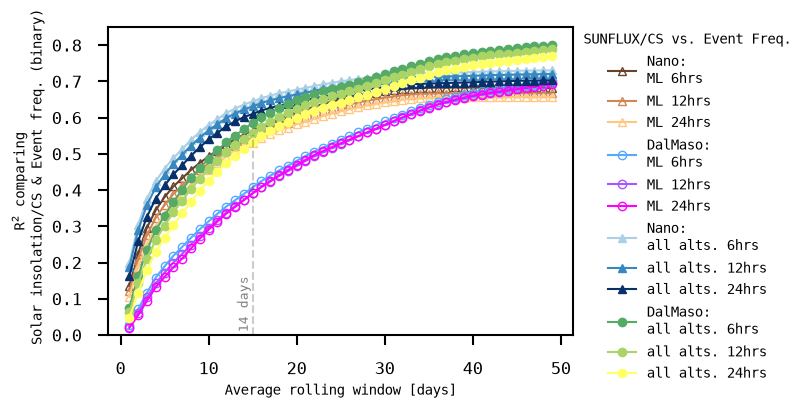

In [52]:
df_SUNCS_Dalmaso6, df_SUNCS_Nano6, df_SUNFLUX_Dalmaso6, df_SUNFLUX_Nano6 = get_r2dfs_events(df_g_timeseries, 
        ZEP_class, df_CS_hourly, time_hrs=6, sun_var='SUN_FLUX')
df_SUNCS_Dalmaso12, df_SUNCS_Nano12, df_SUNFLUX_Dalmaso12, df_SUNFLUX_Nano12 = get_r2dfs_events(df_g_timeseries, 
        ZEP_class, df_CS_hourly, time_hrs=12, sun_var='SUN_FLUX')
df_SUNCS_Dalmaso24, df_SUNCS_Nano24,df_SUNFLUX_Dalmaso24, df_SUNFLUX_Nano24 = get_r2dfs_events(df_g_timeseries, 
        ZEP_class, df_CS_hourly, time_hrs=24, sun_var='SUN_FLUX')

fig, ax = plt.subplots(figsize=(6, 4))

n = 4
cmap = plt.cm.copper
colors = [mpl.colors.rgb2hex(cmap(i)) for i in np.linspace(0, 1, n)]

ax.plot(df_SUNCS_Nano6['windows'], df_SUNCS_Nano6['r2s'], '^-', mfc='None',
        label='Nano:\nML 6hrs', c=colors[1])
ax.plot(df_SUNCS_Nano12['windows'], df_SUNCS_Nano12['r2s'], '^-', mfc='None',
        label='ML 12hrs', c=colors[2])
ax.plot(df_SUNCS_Nano24['windows'], df_SUNCS_Nano24['r2s'], '^-', mfc='None',
        label='ML 24hrs', c=colors[3])

cmap = plt.cm.cool
colors = [mpl.colors.rgb2hex(cmap(i)) for i in np.linspace(0, 1, n)]

ax.plot(df_SUNCS_Dalmaso6['windows'], df_SUNCS_Dalmaso6['r2s'], 'o-', mfc='None',
        label='DalMaso:\nML 6hrs', c=colors[1])
ax.plot(df_SUNCS_Dalmaso12['windows'], df_SUNCS_Dalmaso12['r2s'], 'o-', mfc='None',
        label='ML 12hrs', c=colors[2])
ax.plot(df_SUNCS_Dalmaso24['windows'], df_SUNCS_Dalmaso24['r2s'], 'o-', mfc='None',
        label='ML 24hrs', c=colors[3])

df_SUNCS_Dalmaso6, df_SUNCS_Nano6, df_SUNFLUX_Dalmaso6, df_SUNFLUX_Nano6 = get_r2dfs_events(df_g_timeseries, 
        ZEP_class, df_CS_hourly, time_hrs=6, sun_var='all_sunflux')
df_SUNCS_Dalmaso12, df_SUNCS_Nano12, df_SUNFLUX_Dalmaso12, df_SUNFLUX_Nano12 = get_r2dfs_events(df_g_timeseries, 
        ZEP_class, df_CS_hourly, time_hrs=12, sun_var='all_sunflux')
df_SUNCS_Dalmaso24, df_SUNCS_Nano24,df_SUNFLUX_Dalmaso24, df_SUNFLUX_Nano24 = get_r2dfs_events(df_g_timeseries, 
        ZEP_class, df_CS_hourly, time_hrs=24, sun_var='all_sunflux')

n = 4
cmap = plt.cm.Blues
colors = [mpl.colors.rgb2hex(cmap(i)) for i in np.linspace(0, 1, n)]

ax.plot(df_SUNCS_Nano6['windows'], df_SUNCS_Nano6['r2s'], '^-',
        label='Nano:\nall alts. 6hrs', c=colors[1])
ax.plot(df_SUNCS_Nano12['windows'], df_SUNCS_Nano12['r2s'], '^-',
        label='all alts. 12hrs', c=colors[2])
ax.plot(df_SUNCS_Nano24['windows'], df_SUNCS_Nano24['r2s'], '^-',
        label='all alts. 24hrs', c=colors[3])

cmap = plt.cm.summer
colors = [mpl.colors.rgb2hex(cmap(i)) for i in np.linspace(0, 1, n)]

ax.plot(df_SUNCS_Dalmaso6['windows'], df_SUNCS_Dalmaso6['r2s'], 'o-', 
        label='DalMaso:\nall alts. 6hrs', c=colors[1])
ax.plot(df_SUNCS_Dalmaso12['windows'], df_SUNCS_Dalmaso12['r2s'], 'o-',
        label='all alts. 12hrs', c=colors[2])
ax.plot(df_SUNCS_Dalmaso24['windows'], df_SUNCS_Dalmaso24['r2s'], 'o-',
        label='all alts. 24hrs', c=colors[3])

ax.legend(title='SUNFLUX/CS vs. Event Freq.',           
          bbox_to_anchor=(1.01, 1), borderaxespad=0, frameon=False)
ax.set_ylabel('R$^{2}$ comparing\n Solar insolation/CS & Event freq. (binary)')
ax.set_ylim(0, .85)
ax.set_xlabel('Average rolling window [days]')

ax.axvline(x=15, alpha=.2, color='k', ls='--', ymin=0, ymax=.65,)
ax.text(
    14, 0.1, '14 days',
    rotation=90,
    transform=ax.get_xaxis_transform(),
    ha='center',
    va='center', color='gray', fontsize=9,
)

thickax(ax, fontsize=12)

output_figure = plots_outpath / 'Figure_12.jpeg'
save_plot(fig, output_figure)

In [53]:
def get_r2dfs_intensity(df_g_timeseries, ZEP_class, time_hrs=24, sun_var='SUN_FLUX'):
    df_g_sunflux_cs_D_freq_N = merge(
        df_g_timeseries,
        ZEP_class,
        df_CS_hourly,
        df_intensity=df_timeseries_NintMax,
        time_hrs=time_hrs,
        sun_var=sun_var,
    )
    df_g_sunflux_cs_D_freq_N['SUN_CS'] = (
        df_g_sunflux_cs_D_freq_N[sun_var] / df_g_sunflux_cs_D_freq_N['CS']
    )
    df_SUNCS_intensity = df_r2(df_g_sunflux_cs_D_freq_N, dep_var='SUN_CS', indep_var='N_int_max')
    df_SUNFLUX_intensity = df_r2(df_g_sunflux_cs_D_freq_N, dep_var=sun_var, indep_var='N_int_max')
    return df_SUNCS_intensity, df_SUNFLUX_intensity


Saved: c:\Users\Dell\Documents\PythonProjects\ar-2025-11-ms-code\Plots\Figure_S27.jpeg


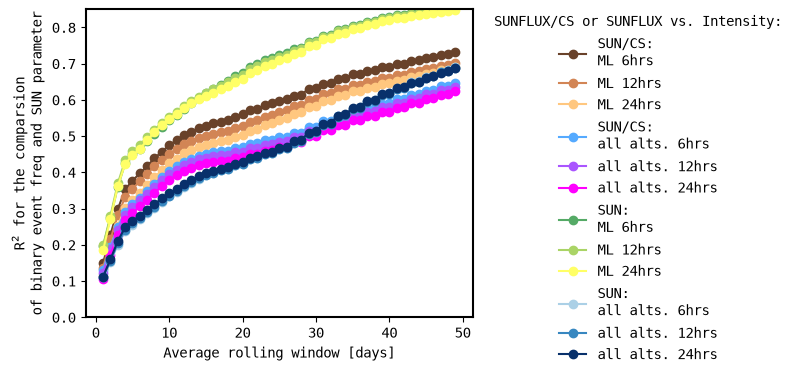

In [54]:
fig, ax = plt.subplots(figsize=(5, 4))

df_SUNCS_intensity6, df_SUNFLUX_intensity6 = get_r2dfs_intensity(df_g_timeseries, 
        ZEP_class, time_hrs=6, sun_var='SUN_FLUX')
df_SUNCS_intensity12, df_SUNFLUX_intensity12 = get_r2dfs_intensity(df_g_timeseries, 
        ZEP_class, time_hrs=12, sun_var='SUN_FLUX')
df_SUNCS_intensity24, df_SUNFLUX_intensity24 = get_r2dfs_intensity(df_g_timeseries, 
        ZEP_class, time_hrs=24, sun_var='SUN_FLUX')

df_SUNCS_intensity_all_6, df_SUNFLUX_intensity_all_6 = get_r2dfs_intensity(df_g_timeseries, 
        ZEP_class, time_hrs=6, sun_var='all_sunflux')
df_SUNCS_intensity_all_12, df_SUNFLUX_intensity_all_12 = get_r2dfs_intensity(df_g_timeseries, 
        ZEP_class, time_hrs=12, sun_var='all_sunflux')
df_SUNCS_intensity_all_24, df_SUNFLUX_intensity_all_24 = get_r2dfs_intensity(df_g_timeseries, 
        ZEP_class, time_hrs=24, sun_var='all_sunflux')

n = 4
cmap = plt.cm.copper
colors = [mpl.colors.rgb2hex(cmap(i)) for i in np.linspace(0, 1, n)]

ax.plot(df_SUNCS_intensity6['windows'], df_SUNCS_intensity6['r2s'], 'o-',
        label='SUN/CS:\nML 6hrs', c=colors[1])
ax.plot(df_SUNCS_intensity12['windows'], df_SUNCS_intensity12['r2s'], 'o-',
        label='ML 12hrs', c=colors[2])
ax.plot(df_SUNCS_intensity24['windows'], df_SUNCS_intensity24['r2s'], 'o-',
        label='ML 24hrs', c=colors[3])

n = 4
cmap = plt.cm.cool
colors = [mpl.colors.rgb2hex(cmap(i)) for i in np.linspace(0, 1, n)]

ax.plot(df_SUNCS_intensity_all_6['windows'], df_SUNCS_intensity_all_6['r2s'], 'o-',
        label='SUN/CS:\nall alts. 6hrs', c=colors[1])
ax.plot(df_SUNCS_intensity_all_12['windows'], df_SUNCS_intensity_all_12['r2s'], 'o-',
        label='all alts. 12hrs', c=colors[2])
ax.plot(df_SUNCS_intensity_all_24['windows'], df_SUNCS_intensity_all_24['r2s'], 'o-',
        label='all alts. 24hrs', c=colors[3])

n = 4
cmap = plt.cm.summer
colors = [mpl.colors.rgb2hex(cmap(i)) for i in np.linspace(0, 1, n)]

ax.plot(df_SUNFLUX_intensity6['windows'], df_SUNFLUX_intensity6['r2s'], 'o-',
        label='SUN:\nML 6hrs', c=colors[1])
ax.plot(df_SUNFLUX_intensity12['windows'], df_SUNFLUX_intensity12['r2s'], 'o-',
        label='ML 12hrs', c=colors[2])
ax.plot(df_SUNFLUX_intensity24['windows'], df_SUNFLUX_intensity24['r2s'], 'o-',
        label='ML 24hrs', c=colors[3])

n = 4
cmap = plt.cm.Blues
colors = [mpl.colors.rgb2hex(cmap(i)) for i in np.linspace(0, 1, n)]

ax.plot(df_SUNFLUX_intensity_all_6['windows'], df_SUNFLUX_intensity_all_6['r2s'], 'o-',
        label='SUN:\nall alts. 6hrs', c=colors[1])
ax.plot(df_SUNFLUX_intensity_all_12['windows'], df_SUNFLUX_intensity_all_12['r2s'], 'o-',
        label='all alts. 12hrs', c=colors[2])
ax.plot(df_SUNFLUX_intensity_all_24['windows'], df_SUNFLUX_intensity_all_24['r2s'], 'o-',
        label='all alts. 24hrs', c=colors[3])

ax.legend(title='SUNFLUX/CS or SUNFLUX vs. Intensity:', 
          bbox_to_anchor=(1.04, 1), borderaxespad=0, frameon=False)

ax.set_ylabel('R$^{2}$ for the comparsion\nof binary event freq and SUN parameter')
ax.set_xlabel('Average rolling window [days]')
ax.set_ylim(0, .85)

output_figure = plots_outpath / 'Figure_S27.jpeg'
save_plot(fig, output_figure)